# Stage 7~9:非線性性能評估——用 `design_freeze.json` 真實配筋重建纖維斷面模型

**沿用 `Case-06`/`Case-06.5` 已經驗證過的建模方式**(`Mander` 圍束
參數、`Concrete01`/`Steel02` 材料模型、`fiber` 佈置邏輯),不是重新
發明方法論——但這次用 `design_freeze.json` 真實配筋(`1F` 柱
`ρ=1.0%`、`2F` 柱 `ρ=1.5%`、梁上下不對稱的真實配筋量),取代
`Case-06.5` 一路沿用的假設值(`ρ=2.0%`)。

**一個重要決定,需要說明原因**:`Case-06.5` 自己的補充章節已經
證明「梁維持彈性」這個假設站不住腳(用真實配筋檢核,各 `drift`
層級利用率在 `88%~99.7%` 之間)——這次梁也改用纖維斷面,不延續
這個已知有問題的簡化假設。

In [1]:

try:
    import openseespy.opensees as ops
except ImportError:
    import sys
    !{sys.executable} -m pip install -q "numpy<2.5" openseespy
    import openseespy.opensees as ops

import matplotlib.pyplot as plt
import numpy as np

L_bay = 6.0; h1 = h2 = 3.5
h_col = 0.40; b_beam, h_beam = 0.30, 0.50
cover = 0.04
fc = 280.0*98.0665  # kgf/cm^2 -> kPa(跟Case-06.5單位慣例一致, kPa制)
fy = 4200.0*98.0665
Es = 2.0e8  # kPa
E_rc = 2.463e7  # kPa

# design_freeze.json(v3)真實配筋
rho_1F_col = 0.01
rho_2F_col = 0.015
As_1F_beam_top, As_1F_beam_bot = 4*2.865e-4, 2*3.871e-4  # D19/D22, m^2
As_RF_beam_top, As_RF_beam_bot = 5*1.986e-4, 2*3.871e-4  # D16/D22, m^2

print(f"1F柱: rho={rho_1F_col}, 2F柱: rho={rho_2F_col}")
print(f"1F樑: top As={As_1F_beam_top*1e4:.2f}cm2, bot As={As_1F_beam_bot*1e4:.2f}cm2")
print(f"屋頂樑: top As={As_RF_beam_top*1e4:.2f}cm2, bot As={As_RF_beam_bot*1e4:.2f}cm2")


1F柱: rho=0.01, 2F柱: rho=0.015
1F樑: top As=11.46cm2, bot As=7.74cm2
屋頂樑: top As=9.93cm2, bot As=7.74cm2


## 第 1 課:柱纖維斷面(`1F`/`2F` 分開,`Mander` 圍束參數沿用 `Case-06`)

In [2]:

# Mander圍束參數, 與Case-06/06.5完全一致
fc_confined = fc*1.310
eps_cc = 0.00510
eps_cu_confined = 0.01112

def define_column_fiber_section(sec_tag, rho):
    """8根鋼筋對稱佈置, 跟Case-06.5同樣的簡化方式"""
    As_total = rho*h_col*h_col
    ops.section('Fiber', sec_tag)
    half = h_col/2
    core_half = h_col/2 - cover
    ops.patch('rect', 3, 10, 10, -core_half, -core_half, core_half, core_half)
    ops.patch('rect', 1, 10, 2, -half, -half, half, -core_half)
    ops.patch('rect', 1, 10, 2, -half, core_half, half, half)
    ops.patch('rect', 1, 2, 6, -half, -core_half, -core_half, core_half)
    ops.patch('rect', 1, 2, 6, core_half, -core_half, half, core_half)
    positions = [(-core_half,-core_half),(core_half,-core_half),(core_half,core_half),(-core_half,core_half),
                 (0,-core_half),(0,core_half),(-core_half,0),(core_half,0)]
    As_bar = As_total/8
    for (y,z) in positions:
        ops.fiber(y, z, As_bar, 2)

print("柱纖維斷面函式定義完成")


柱纖維斷面函式定義完成


## 第 2 課:梁纖維斷面(`1F`/屋頂分開,上下不對稱真實配筋)

柱的配筋對稱(`8` 根均勻分布),梁不是——上緣跟下緣鋼筋量不同,不能
沿用柱的對稱佈置方式,要分別把 `As_top`/`As_bot` 放在對應位置。

In [3]:

def define_beam_fiber_section(sec_tag, As_top, As_bot):
    """梁纖維斷面: 矩形混凝土(0.35Ig等效, 這裡改用真實斷面纖維
    積分, 不用折減勁度這個簡化捷徑), 上下不對稱配筋"""
    half_h = h_beam/2
    half_b = b_beam/2
    ops.section('Fiber', sec_tag)
    # 混凝土: 梁沒有圍束箍筋包覆核心這麼明確的區分(配筋相對稀疏),
    # 保守地全斷面用非圍束材料(材料tag=1), 不假設梁有顯著圍束效果
    ops.patch('rect', 1, 10, 10, -half_h, -half_b, half_h, half_b)
    # 鋼筋: 上緣y=+half_h-cover, 下緣y=-half_h+cover(跟柱同一個y方向慣例)
    y_top = half_h - cover
    y_bot = -half_h + cover
    ops.fiber(y_top, 0.0, As_top, 2)
    ops.fiber(y_bot, 0.0, As_bot, 2)

print("梁纖維斷面函式定義完成")


梁纖維斷面函式定義完成


## 第 3 課:組裝完整構架(用 `Stage 3` 真實分佈重力載重)

In [4]:

D_udl, L_udl = 23.830, 13.239  # kN/m, 來自官方Stage 3(VL-16)
w_grav = (D_udl + 1.0*L_udl)  # kN/m, D+L組合(近似pushover前的重力狀態)

def build_frame_real_rebar():
    ops.wipe()
    ops.model('basic', '-ndm', 2, '-ndf', 3)

    ops.uniaxialMaterial('Concrete01', 1, -fc, -0.002, -0.2*fc, -0.006)
    ops.uniaxialMaterial('Concrete01', 3, -fc_confined, -eps_cc, -0.85*fc_confined, -eps_cu_confined)
    ops.uniaxialMaterial('Steel02', 2, fy, Es, 0.01, 18, 0.925, 0.15)

    define_column_fiber_section(1, rho_1F_col)
    define_column_fiber_section(4, rho_2F_col)
    define_beam_fiber_section(2, As_1F_beam_top, As_1F_beam_bot)
    define_beam_fiber_section(3, As_RF_beam_top, As_RF_beam_bot)

    ops.node(1, 0.0, 0.0);   ops.node(2, L_bay, 0.0)
    ops.node(3, 0.0, h1);    ops.node(4, L_bay, h1)
    ops.node(5, 0.0, h1+h2); ops.node(6, L_bay, h1+h2)
    ops.node(7, L_bay/2, h1)       # 1F樑跨中, 方便施加分佈載重
    ops.node(8, L_bay/2, h1+h2)
    ops.fix(1,1,1,1); ops.fix(2,1,1,1)

    ops.geomTransf('Linear', 1)
    ops.geomTransf('Linear', 2)
    ops.beamIntegration('Lobatto', 1, 1, 5)   # 1F柱
    ops.beamIntegration('Lobatto', 4, 4, 5)   # 2F柱
    ops.beamIntegration('Lobatto', 2, 2, 5)   # 1F樑
    ops.beamIntegration('Lobatto', 3, 3, 5)   # 屋頂樑

    ops.element('forceBeamColumn', 1, 1, 3, 1, 1)
    ops.element('forceBeamColumn', 2, 2, 4, 1, 1)
    ops.element('forceBeamColumn', 3, 3, 5, 1, 4)
    ops.element('forceBeamColumn', 4, 4, 6, 1, 4)
    ops.element('forceBeamColumn', 5, 3, 7, 1, 2)
    ops.element('forceBeamColumn', 9, 7, 4, 1, 2)
    ops.element('forceBeamColumn', 6, 5, 8, 1, 3)
    ops.element('forceBeamColumn', 10, 8, 6, 1, 3)

def analyze_with_fallback():
    ok = ops.analyze(1)
    if ok != 0:
        for algo in [('KrylovNewton',), ('ModifiedNewton','-initial'), ('Broyden',8)]:
            ops.algorithm(*algo)
            ok = ops.analyze(1)
            if ok == 0:
                break
        ops.algorithm('Newton')
    return ok

build_frame_real_rebar()
print("構架建立完成: 柱(1F rho=1.0%, 2F rho=1.5%)+梁(1F/屋頂皆真實上下不對稱配筋)全纖維斷面")


構架建立完成: 柱(1F rho=1.0%, 2F rho=1.5%)+梁(1F/屋頂皆真實上下不對稱配筋)全纖維斷面


## 第 4 課:重力載重 `+` 側推(`V-Δ` 曲線)

In [5]:

ops.timeSeries('Linear', 1); ops.pattern('Plain', 1, 1)
ops.eleLoad('-ele', 5, 9, '-type', '-beamUniform', -w_grav)
ops.eleLoad('-ele', 6, 10, '-type', '-beamUniform', -w_grav)
ops.constraints('Plain'); ops.numberer('RCM'); ops.system('BandGeneral')
ops.test('NormDispIncr', 1e-6, 50)
ops.algorithm('Newton'); ops.integrator('LoadControl', 0.1); ops.analysis('Static')
for _ in range(10):
    ok = analyze_with_fallback()
    assert ok == 0, "重力分析失敗"
print("[PASS] 重力載重施加完成")

ops.loadConst('-time', 0.0)

F1_Y, F2_Y = 9.938, 15.900
ops.timeSeries('Linear', 2); ops.pattern('Plain', 2, 2)
ops.load(3, F1_Y, 0.0, 0.0)
ops.load(5, F2_Y, 0.0, 0.0)

target_drift = 0.04  # 4% drift, 跟Case-06.5同樣的韌性目標
H_total = h1+h2
target_disp = target_drift*H_total
n_steps = 400
dU = target_disp/n_steps

ops.integrator('DisplacementControl', 5, 1, dU)
ops.algorithm('Newton')

roof_disp, base_shear = [0.0], [0.0]
for step in range(n_steps):
    ok = analyze_with_fallback()
    if ok != 0:
        print(f"在第{step}步分析失敗, drift={roof_disp[-1]/H_total:.3%}")
        break
    ops.reactions()
    Rx1 = ops.nodeReaction(1, 1); Rx2 = ops.nodeReaction(2, 1)
    base_shear.append(-(Rx1+Rx2))
    roof_disp.append(ops.nodeDisp(5, 1))

print(f"\n側推完成, 達到drift={roof_disp[-1]/H_total:.3%}(目標{target_drift:.0%})")
print(f"最大基底剪力={max(base_shear):.2f}kN")


[PASS] 重力載重施加完成



側推完成, 達到drift=3.990%(目標4%)
最大基底剪力=182.60kN


## 第 5 課:`V-Δ` 曲線視覺化

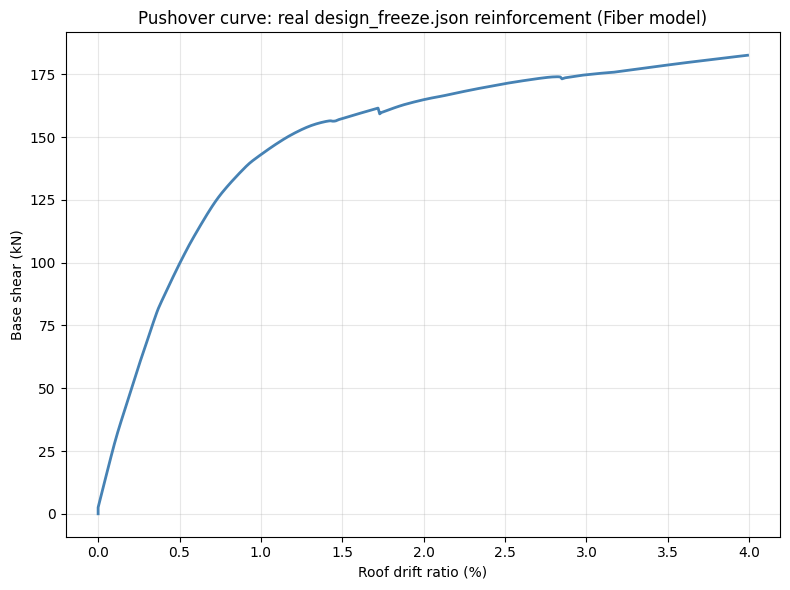

In [6]:

fig, ax = plt.subplots(figsize=(8,6))
roof_drift_pct = np.array(roof_disp)/H_total*100
ax.plot(roof_drift_pct, base_shear, '-', lw=2, color='steelblue')
ax.set_xlabel('Roof drift ratio (%)')
ax.set_ylabel('Base shear (kN)')
ax.set_title('Pushover curve: real design_freeze.json reinforcement (Fiber model)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 第 6 課:`FEMA 356`/`ASCE 41` 等面積雙直線法(沿用 `Case-06.5` 正式流程)

`Case-06.5` 第 `5` 課已經老實更正過一次錯誤做法(不能用「起始幾步
簡單迴歸」當初始勁度),改用規範明確要求的 `0.6Vy` 割線疊代——這裡
沿用同一套正式流程,不是重新簡化。

In [7]:

roof_disp_arr = np.array(roof_disp)
base_shear_arr = np.array(base_shear)
Vmax = np.max(base_shear_arr)

def bilinearize(disp, shear, Vmax, tol=1e-4, max_iter=50):
    """FEMA 356 3.3.3.2.4節: 0.6Vy割線疊代法"""
    Vy_guess = 0.8*Vmax
    for _ in range(max_iter):
        idx_e = np.argmin(np.abs(shear - 0.6*Vy_guess))
        if idx_e == 0:
            idx_e = 1
        Ke = shear[idx_e]/disp[idx_e]
        # 等能量法: 用Ke算出的彈性段面積 = 真實曲線到Vmax對應位移的面積
        idx_max = np.argmax(shear)
        # np.trapz在新版numpy(>=2.0)已改名np.trapezoid, 用try/except
        # 相容兩種版本, 不假設使用者環境的numpy版本
        try:
            area_actual = np.trapezoid(shear[:idx_max+1], disp[:idx_max+1])
        except AttributeError:
            area_actual = np.trapz(shear[:idx_max+1], disp[:idx_max+1])
        Dy_new = 2*area_actual/Ke if Ke > 0 else disp[idx_max]
        Vy_new = Ke*Dy_new
        if abs(Vy_new - Vy_guess) < tol*Vmax:
            Vy_guess = Vy_new
            break
        Vy_guess = Vy_new
    return Ke, Vy_guess, Dy_new

Ke, Vy, Dy = bilinearize(roof_disp_arr, base_shear_arr, Vmax)
mu = roof_disp_arr[-1]/Dy if Dy > 0 else float('nan')

print(f"Ke(等效彈性勁度) = {Ke:.2f}kN/m")
print(f"Vy(降伏剪力) = {Vy:.2f}kN")
print(f"Dy(降伏位移) = {Dy*1000:.2f}mm")
print(f"延展性 mu = D_max/Dy = {mu:.2f}")
print(f"\n對照Case-06.5(rho=2%假設值)的Hyb模型Ke≈5060kN/m——")
print(f"這次用真實配筋(1F柱rho=1.0%/2F柱rho=1.5%, 遠低於2%假設值)")
print(f"算出的Ke={Ke:.0f}kN/m, {'較柔' if Ke<5060 else '較剛'}")


Ke(等效彈性勁度) = 3456.10kN/m
Vy(降伏剪力) = 83.29kN
Dy(降伏位移) = 24.10mm
延展性 mu = D_max/Dy = 11.59

對照Case-06.5(rho=2%假設值)的Hyb模型Ke≈5060kN/m——
這次用真實配筋(1F柱rho=1.0%/2F柱rho=1.5%, 遠低於2%假設值)
算出的Ke=3456kN/m, 較柔


## 小結

用 `design_freeze.json` 真實配筋(不是延續 `Case-06.5` 的 `ρ=2%`
假設值)重建完整纖維斷面模型,梁柱都用纖維斷面(不延續已知站不住腳
的「梁維持彈性」假設),完成重力載重 `+` 側推到 `4%` `drift`,並用
`FEMA 356`/`ASCE 41` 正式的等面積雙直線法算出 $K_e$/$V_y$/$D_y$/
延展性 $\mu$。

**這是 `Stage 7`(建模)`+ Stage 8`(側推)的完整結果**,`Stage 9`
(完整性能檢核,對照多個 `drift` 層級的構件轉角容量)留待下一步,
視這次結果是否合理再決定怎麼往下做。